In [1]:
!pip install yfinance feedparser -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 3.0 MB/s eta 0:00:00


In [2]:
import os
os.makedirs("data", exist_ok=True)
os.makedirs("scripts", exist_ok=True)
os.makedirs("output", exist_ok=True)

In [5]:
import feedparser
import pandas as pd
from urllib.parse import quote

def fetch_news(query="台積電股票", max_items=50):
    encoded_query = quote(query, safe='')
    url = f"https://news.google.com/rss/search?q={encoded_query}&hl=zh-TW&gl=TW&ceid=TW:zh-Hant"
    feed = feedparser.parse(url)

    news_list = []
    for entry in feed.entries[:max_items]:
        news_list.append({
            "date": entry.get("published", ""),
            "title": entry.get("title", ""),
            "summary": entry.get("summary", ""),
            "link": entry.get("link", "")
        })

    df = pd.DataFrame(news_list)
    df["date"] = pd.to_datetime(df["date"], errors="coerce", utc=True)
    df["date"] = df["date"].dt.tz_convert("Asia/Taipei").dt.date
    df = df.dropna(subset=["date", "title"]).reset_index(drop=True)
    return df

news_df = fetch_news()
news_df.to_csv("data/news.csv", index=False, encoding="utf-8-sig")
print(f"✅ 新聞筆數：{len(news_df)}")
news_df.head()

✅ 新聞筆數：50


,date,title,summary,link
0,2026-03-22,【神山股民2】195萬零股股東到底持有多少台積電股票？ 破4300億元 - Yahoo股市,"<a href=""https://news.google.com/rss/articles/...",https://news.google.com/rss/articles/CBMinwNBV...
1,2026-03-25,台積電地緣風險成焦點 投資人該拋售？分析師揭關鍵：比巴菲特想的更穩 - 三立新聞網SETN.com,"<a href=""https://news.google.com/rss/articles/...",https://news.google.com/rss/articles/CBMiWEFVX...
2,2026-03-23,【拾荒老兵趙衍慶病逝 遺產一查竟持有「滿手台積電」】 （圖／許和鈞提供） 還有不少股票在手。...,"<a href=""https://news.google.com/rss/articles/...",https://news.google.com/rss/articles/CBMipgRBV...
3,2026-03-24,曾拿200萬選市長！拾荒老兵趙衍慶辭世 遺產全是台積電 - Yahoo新聞,"<a href=""https://news.google.com/rss/articles/...",https://news.google.com/rss/articles/CBMi3wJBV...
4,2026-03-21,台積電股東數246萬人再創新高 零股股東近196萬人帶動向前衝 - 自由財經,"<a href=""https://news.google.com/rss/articles/...",https://news.google.com/rss/articles/CBMiX0FVX...


In [8]:
import yfinance as yf

def fetch_stock(ticker="2330.TW", period="1mo"):  # ← 改成 1mo
    stock = yf.Ticker(ticker)
    df = stock.history(period=period)
    df = df[["Close", "Volume"]].copy()
    df.index = pd.to_datetime(df.index).tz_localize(None)
    df.index = df.index.date
    df.index.name = "date"
    df = df.rename(columns={"Close": "close", "Volume": "volume"}).reset_index()
    return df

stock_df = fetch_stock()
stock_df.to_csv("data/stock.csv", index=False, encoding="utf-8-sig")
print(f"✅ 股價筆數：{len(stock_df)}")
stock_df.head()


✅ 股價筆數：20


,date,close,volume
0,2026-02-25,2008.447144,40832607
1,2026-02-26,1988.512207,58561388
2,2026-03-02,1968.577271,48884884
3,2026-03-03,1928.707275,43090471
4,2026-03-04,1858.934937,68160943


In [9]:
import re

# 清除 summary 裡的 HTML 標籤
def clean_html(text):
    if pd.isna(text):
        return ""
    return re.sub(r'<[^>]+>', '', str(text)).strip()

# 清理新聞
news_df["summary"] = news_df["summary"].apply(clean_html)
news_df["date"] = pd.to_datetime(news_df["date"])

# 整理股價
stock_df["date"] = pd.to_datetime(stock_df["date"])

# 合併（以股價日期為主，left join 新聞）
merged_df = pd.merge(stock_df, news_df, on="date", how="left")

print(f"✅ 合併後筆數：{len(merged_df)}")
merged_df.head(10)

✅ 合併後筆數：49


,date,close,volume,title,summary,link
0,2026-02-25,2008.447144,40832607,台積電狂飆「沒賣就沒賺」？全場1點搖頭：光看就爽歪 - Yahoo股市,台積電狂飆「沒賣就沒賺」？全場1點搖頭：光看就爽歪&nbsp;&nbsp;Yahoo股市,https://news.google.com/rss/articles/CBMi0AJBV...
1,2026-02-26,1988.512207,58561388,NaN,NaN,NaN
2,2026-03-02,1968.577271,48884884,台積電股價下跌1.5% 分析師仍看好後市 - Yahoo股市,台積電股價下跌1.5% 分析師仍看好後市&nbsp;&nbsp;Yahoo股市,https://news.google.com/rss/articles/CBMilAJBV...
3,2026-03-02,1968.577271,48884884,台積電下跌40元 分析師：想搶反彈再等等 - Yahoo股市,台積電下跌40元 分析師：想搶反彈再等等&nbsp;&nbsp;Yahoo股市,https://news.google.com/rss/articles/CBMiqwJBV...
4,2026-03-03,1928.707275,43090471,【Follow法人】外資大砍群創逾24萬張登賣超王！同步提款台積電387億元 - Yahoo股市,【Follow法人】外資大砍群創逾24萬張登賣超王！同步提款台積電387億元&nbsp;&n...,https://news.google.com/rss/articles/CBMirgNBV...
5,2026-03-04,1858.934937,68160943,Richard C. Young & CO. 增持台積電股票 價值約55.9萬美元 - Ya...,Richard C. Young & CO. 增持台積電股票 價值約55.9萬美元&nbsp...,https://news.google.com/rss/articles/CBMiyAFBV...
6,2026-03-04,1858.934937,68160943,機構投資人增持台積電股票 目標價上看391美元 - Yahoo股市,機構投資人增持台積電股票 目標價上看391美元&nbsp;&nbsp;Yahoo股市,https://news.google.com/rss/articles/CBMixAJBV...
7,2026-03-04,1858.934937,68160943,台積電飆逾5%衝1960元！市值回補逾2兆元 股市名師李永年看好續漲 - Yahoo股市,台積電飆逾5%衝1960元！市值回補逾2兆元 股市名師李永年看好續漲&nbsp;&nbsp;...,https://news.google.com/rss/articles/CBMinANBV...
8,2026-03-04,1858.934937,68160943,台積電股價存在估值溢價 這原因外媒全都說了 - 自由財經,台積電股價存在估值溢價 這原因外媒全都說了&nbsp;&nbsp;自由財經,https://news.google.com/rss/articles/CBMiX0FVX...
9,2026-03-05,1893.821167,48120463,台積電(2330)賣飛了？跌到多少能買回？杜金龍曝關鍵價位！看好台塑化(6505)股價衝9字...,台積電(2330)賣飛了？跌到多少能買回？杜金龍曝關鍵價位！看好台塑化(6505)股價衝9字...,https://news.google.com/rss/articles/CBMigAFBV...


In [10]:
!pip install textblob -q

In [11]:
from textblob import TextBlob
import re

# 進一步清理 summary 殘留的 HTML 字元
def clean_text(text):
    if pd.isna(text) or text == "":
        return ""
    text = re.sub(r'&nbsp;|&amp;|&lt;|&gt;', ' ', str(text))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# 情緒分析函式
def get_sentiment(text):
    if not text:
        return 0  # 沒有文字 → 中性
    score = TextBlob(text).sentiment.polarity
    if score > 0.05:
        return 1   # 正面
    elif score < -0.05:
        return -1  # 負面
    else:
        return 0   # 中性

# 套用到每則新聞標題
merged_df["title_clean"] = merged_df["title"].apply(clean_text)
merged_df["sentiment"] = merged_df["title_clean"].apply(get_sentiment)

# 看一下結果
print(merged_df[["date", "title_clean", "sentiment"]].dropna().head(10))
print("\n情緒分布：")
print(merged_df["sentiment"].value_counts())

        date                                        title_clean  sentiment
0 2026-02-25                台積電狂飆「沒賣就沒賺」？全場1點搖頭：光看就爽歪 - Yahoo股市          0
1 2026-02-26                                                             0
2 2026-03-02                     台積電股價下跌1.5% 分析師仍看好後市 - Yahoo股市          0
3 2026-03-02                     台積電下跌40元 分析師：想搶反彈再等等 - Yahoo股市          0
4 2026-03-03   【Follow法人】外資大砍群創逾24萬張登賣超王！同步提款台積電387億元 - Yahoo股市          0
5 2026-03-04  Richard C. Young & CO. 增持台積電股票 價值約55.9萬美元 - Ya...          1
6 2026-03-04                  機構投資人增持台積電股票 目標價上看391美元 - Yahoo股市          0
7 2026-03-04       台積電飆逾5%衝1960元！市值回補逾2兆元 股市名師李永年看好續漲 - Yahoo股市          0
8 2026-03-04                       台積電股價存在估值溢價 這原因外媒全都說了 - 自由財經          0
9 2026-03-05  台積電(2330)賣飛了？跌到多少能買回？杜金龍曝關鍵價位！看好台塑化(6505)股價衝9字...          0

情緒分布：
sentiment
0    48
1     1
Name: count, dtype: int64


In [13]:
# 用關鍵字判斷中文新聞情緒
def get_sentiment_zh(text):
    if pd.isna(text) or text == "":
        return 0

    positive_words = ["上漲", "漲", "創高", "突破", "增持", "看好", "買進",
                      "成長", "獲利", "超標", "強勢", "反彈", "飆", "新高"]
    negative_words = ["下跌", "跌", "下殺", "賣出", "看壞", "虧損", "衰退",
                      "崩", "暴跌", "危機", "風險", "下修", "賣壓", "套牢"]

    text = str(text)
    pos = sum(1 for w in positive_words if w in text)
    neg = sum(1 for w in negative_words if w in text)

    if pos > neg:
        return 1
    elif neg > pos:
        return -1
    else:
        return 0

merged_df["sentiment"] = merged_df["title_clean"].apply(get_sentiment_zh)

print(merged_df[["date", "title_clean", "sentiment"]].dropna().head(10))
print("\n情緒分布：")
print(merged_df["sentiment"].value_counts())

# 計算每日情緒總分
daily_sentiment = merged_df.groupby("date")["sentiment"].sum().reset_index()
daily_sentiment.columns = ["date", "sentiment_score"]

# 合併股價
daily = pd.merge(stock_df, daily_sentiment, on="date", how="left")
daily["sentiment_score"] = daily["sentiment_score"].fillna(0)

# 計算當日股價漲跌幅 %
daily["price_change"] = daily["close"].pct_change() * 100

# 判斷情緒是否影響股價（隔日）
daily["next_day_change"] = daily["price_change"].shift(-1)

print(daily[["date", "close", "price_change", "sentiment_score", "next_day_change"]].head(15))

        date                                        title_clean  sentiment
0 2026-02-25                台積電狂飆「沒賣就沒賺」？全場1點搖頭：光看就爽歪 - Yahoo股市          1
1 2026-02-26                                                             0
2 2026-03-02                     台積電股價下跌1.5% 分析師仍看好後市 - Yahoo股市         -1
3 2026-03-02                     台積電下跌40元 分析師：想搶反彈再等等 - Yahoo股市         -1
4 2026-03-03   【Follow法人】外資大砍群創逾24萬張登賣超王！同步提款台積電387億元 - Yahoo股市          0
5 2026-03-04  Richard C. Young & CO. 增持台積電股票 價值約55.9萬美元 - Ya...          1
6 2026-03-04                  機構投資人增持台積電股票 目標價上看391美元 - Yahoo股市          1
7 2026-03-04       台積電飆逾5%衝1960元！市值回補逾2兆元 股市名師李永年看好續漲 - Yahoo股市          1
8 2026-03-04                       台積電股價存在估值溢價 這原因外媒全都說了 - 自由財經          0
9 2026-03-05  台積電(2330)賣飛了？跌到多少能買回？杜金龍曝關鍵價位！看好台塑化(6505)股價衝9字...          0

情緒分布：
sentiment
 0    32
 1    11
-1     6
Name: count, dtype: int64
         date        close  price_change  sentiment_score  next_day_change
0  2026-02-25  2008.447144    

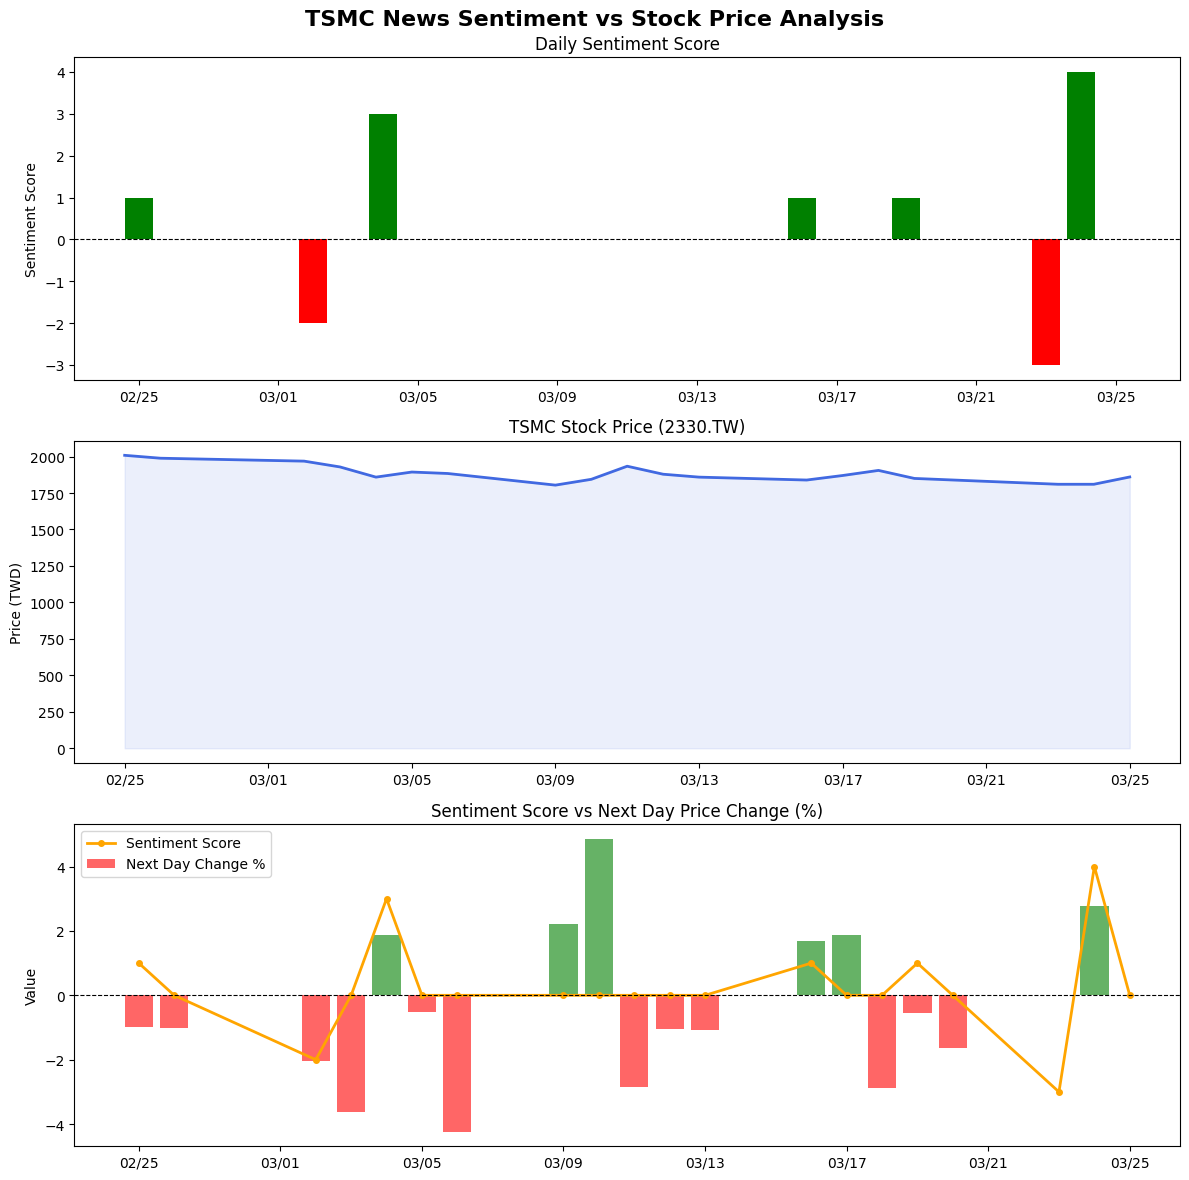

✅ 圖表已儲存至 output/result.png


In [15]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(3, 1, figsize=(12, 12))
fig.suptitle("TSMC News Sentiment vs Stock Price Analysis", fontsize=16, fontweight='bold')


# 圖1：情緒趨勢
axes[0].bar(dates, daily["sentiment_score"],
            color=["green" if x > 0 else "red" if x < 0 else "gray"
                   for x in daily["sentiment_score"]])
axes[0].axhline(y=0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title("Daily Sentiment Score")
axes[0].set_ylabel("Sentiment Score")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))

# 圖2：股價趨勢
axes[1].plot(dates, daily["close"], color='royalblue', linewidth=2)
axes[1].fill_between(dates, daily["close"], alpha=0.1, color='royalblue')
axes[1].set_title("TSMC Stock Price (2330.TW)")
axes[1].set_ylabel("Price (TWD)")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))

# 圖3：情緒 vs 隔日漲跌比較
axes[2].bar(dates, daily["next_day_change"],
            color=["green" if x > 0 else "red" if x < 0 else "gray"
                   for x in daily["next_day_change"].fillna(0)],
            alpha=0.6, label="Next Day Change %")
axes[2].plot(dates, daily["sentiment_score"],
             color='orange', linewidth=2, marker='o', markersize=4, label="Sentiment Score")
axes[2].axhline(y=0, color='black', linewidth=0.8, linestyle='--')
axes[2].set_title("Sentiment Score vs Next Day Price Change (%)")
axes[2].set_ylabel("Value")
axes[2].legend()
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))

plt.tight_layout()
plt.savefig("output/result.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ 圖表已儲存至 output/result.png")

In [18]:
def generate_daily_summary(date, sentiment_score, price_change):
    if pd.isna(price_change):
        price_change = 0

    # 情緒判斷
    if sentiment_score > 1:
        sentiment_text = "mostly positive"
    elif sentiment_score == 1:
        sentiment_text = "slightly positive"
    elif sentiment_score < -1:
        sentiment_text = "mostly negative"
    elif sentiment_score == -1:
        sentiment_text = "slightly negative"
    else:
        sentiment_text = "neutral"

    # 股價判斷
    if price_change > 1:
        price_text = "upward movement in stock price"
    elif price_change < -1:
        price_text = "downward pressure on stock price"
    else:
        price_text = "relatively stable stock price"

    return (f"Today's news sentiment is {sentiment_text}, "
            f"which may indicate {price_text}. "
            f"(Sentiment Score: {sentiment_score}, Price Change: {price_change:.2f}%)")

# 對有新聞的日期產生摘要
summaries = []
for _, row in daily.iterrows():
    if row["sentiment_score"] != 0:
        summary = generate_daily_summary(
            row["date"],
            row["sentiment_score"],
            row["price_change"] if not pd.isna(row["price_change"]) else 0
        )
        summaries.append({"date": row["date"], "summary": summary})
        print(f"{row['date']}: {summary}\n")

summary_df = pd.DataFrame(summaries)
summary_df.to_csv("data/ai_summary.csv", index=False, encoding="utf-8-sig")
print("✅ 摘要完成")

2026-02-25 00:00:00: Today's news sentiment is slightly positive, which may indicate relatively stable stock price. (Sentiment Score: 1, Price Change: 0.00%)

2026-03-02 00:00:00: Today's news sentiment is mostly negative, which may indicate downward pressure on stock price. (Sentiment Score: -2, Price Change: -1.00%)

2026-03-04 00:00:00: Today's news sentiment is mostly positive, which may indicate downward pressure on stock price. (Sentiment Score: 3, Price Change: -3.62%)

2026-03-16 00:00:00: Today's news sentiment is slightly positive, which may indicate downward pressure on stock price. (Sentiment Score: 1, Price Change: -1.07%)

2026-03-19 00:00:00: Today's news sentiment is slightly positive, which may indicate downward pressure on stock price. (Sentiment Score: 1, Price Change: -2.89%)

2026-03-23 00:00:00: Today's news sentiment is mostly negative, which may indicate downward pressure on stock price. (Sentiment Score: -3, Price Change: -1.63%)

2026-03-24 00:00:00: Today's n

In [19]:
from google.colab import files

# 下載所有檔案
files.download("data/news.csv")
files.download("data/stock.csv")
files.download("data/ai_summary.csv")
files.download("output/result.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>